Abstract 
This paper proposes an NLP-based semantic search system for academic library resources, designed to improve information retrieval using natural language queries. A structured metadata dataset was developed from university library records, integrating both physical and digital resources. The system employs TF-IDF vectorization and cosine similarity to identify relevant materials based on user queries. A comparative analysis was conducted against traditional keyword-based search methods, demonstrating improved retrieval performance. Additionally, data visualization techniques were applied to analyze library content distribution and identify gaps in resource availability. The results indicate that the proposed system enhances search accuracy and user experience in academic environments.

Introduction 
Traditional library catalog systems rely on keyword-based search, which often fails to capture the semantic meaning of user queries. With the growth of digital resources, there is a need for intelligent search systems that can understand natural language. This study aims to develop an NLP-based semantic search system to improve accessibility and usability of academic library resources.

Methodology (Core Section)
Include:
*Dataset construction
*Preprocessing
*TF-IDF model
*Similarity calculation
*Evaluation

Results
Use:
*Precision / Recall / F1 results
*Graphs you created
*Comparison table

Conclusion

The proposed system successfully enhances library search capabilities by incorporating semantic understanding. Compared to traditional keyword-based systems, the model demonstrated improved retrieval performance and user relevance. Future work may include integrating deep learning models such as transformer-based embeddings and real-time user interaction analysis.

In [1]:
import pandas as pd

Load Dataset

In [4]:
import pandas as pd

file_path = "../data/library_data.csv"

df = pd.read_csv(file_path, encoding="utf-8", on_bad_lines="skip")

df.head()

,id,العنوان,تصنيف ديوي,المؤلف,الهيئة,الملتقى,تصنيف الكونجرس,تصنيف محلى,المواضيع,تاريخ النشر,...,مكان النشر,الرقم الدولي المعياري,ملاحظات,رابط النسخة اﻹلكترونية للكتاب,marc_raw,framework_id,item_type_id,branche_id,branches_list,reference_ids
0,133762,تحفة الابرار : في الاذكار الواردة في كتاب الل...,NaN,القنوبي الشيخ العلامة سعيد بن مبروك,NaN,NaN,BP188.Q3 .C36 2011,NaN,التزكية والأخلاق,2011,...,سلطنة عمان,NaN,أهمية الذكر -- ذكر أقوال طائفة من العلماء قي ا...,NaN,00903 2200157 45000080041000000400019000...,12,1,10,NaN,NaN
1,133788,العادات السبع للناس الأكثر فعالية : دروس فعال...,NaN,كوفي. ستيفن آر,كولينز. جيم,NaN,BF637.S8 .C68 2019,NaN,"النجاح , العلاقات الشخصية",2019,...,الرياض,NaN,NaN,NaN,01156 2200229 45000080041000000400019000...,12,1,10,NaN,NaN
2,133761,قناص الحياة.,NaN,مدرك بن سعيد بن علي الحراصي,عبدالله النبهاني,NaN,BP190.5.S36 H373 2011,NaN,"تحقيق الذات , أسلوب الحياة , جوانب دينية",2011,...,روي، سلطنة عمان,NaN,ما هي مهارة القنص الحقيقية--من هو قناص الحياة-...,NaN,01062 2200241 45000080041000000400019000...,12,1,10,NaN,NaN
3,134066,Repair of vehicle bodies / A. Robinson ; updat...,NaN,Robinson A,Livesey Andrew,NaN,TL255 .R56 2005,NaN,Automobiles,2005,...,Oxford,0750667532,Health and safety--Hand and power tools--Metho...,NaN,00811 2200193 45000080041000000200015000...,12,1,10,NaN,NaN
4,134105,30Day GMAT Success : !How I Scored 780 on the...,650.076,Wu Brandon,NaN,NaN,HF1118 .W83 2011,NaN,"Management , Business , GMAT Test Preparation",2011,...,"Covina, Calif",9780983170112,GMAT success Principles-- The GMAT --GMAT Verb...,NaN,00777 2200241 45000080041000000200018000...,12,1,10,NaN,NaN


Clean Column Names

In [5]:
df.columns = df.columns.str.strip()
df.columns

Index(['id', 'العنوان', 'تصنيف ديوي', 'المؤلف', 'الهيئة', 'الملتقى',
       'تصنيف الكونجرس', 'تصنيف محلى', 'المواضيع', 'تاريخ النشر', 'اسم الناشر',
       'مكان النشر', 'الرقم الدولي المعياري', 'ملاحظات',
       'رابط النسخة اﻹلكترونية للكتاب', 'marc_raw', 'framework_id',
       'item_type_id', 'branche_id', 'branches_list', 'reference_ids'],
      dtype='object')

Clean Column Names

In [6]:
df.columns = df.columns.str.strip()
df.columns

Index(['id', 'العنوان', 'تصنيف ديوي', 'المؤلف', 'الهيئة', 'الملتقى',
       'تصنيف الكونجرس', 'تصنيف محلى', 'المواضيع', 'تاريخ النشر', 'اسم الناشر',
       'مكان النشر', 'الرقم الدولي المعياري', 'ملاحظات',
       'رابط النسخة اﻹلكترونية للكتاب', 'marc_raw', 'framework_id',
       'item_type_id', 'branche_id', 'branches_list', 'reference_ids'],
      dtype='object')

Select Important Columns

In [7]:
selected_columns = [
    "id",
    "العنوان",
    "المؤلف",
    "المواضيع",
    "ملاحظات",
    "تاريخ النشر",
    "اسم الناشر",
    "مكان النشر",
    "الرقم الدولي المعياري",
    "تصنيف الكونجرس"
]

library_df = df[selected_columns].copy()

library_df.head()

,id,العنوان,المؤلف,المواضيع,ملاحظات,تاريخ النشر,اسم الناشر,مكان النشر,الرقم الدولي المعياري,تصنيف الكونجرس
0,133762,تحفة الابرار : في الاذكار الواردة في كتاب الل...,القنوبي الشيخ العلامة سعيد بن مبروك,التزكية والأخلاق,أهمية الذكر -- ذكر أقوال طائفة من العلماء قي ا...,2011,المكتبة السعيدية,سلطنة عمان,NaN,BP188.Q3 .C36 2011
1,133788,العادات السبع للناس الأكثر فعالية : دروس فعال...,كوفي. ستيفن آر,"النجاح , العلاقات الشخصية",NaN,2019,مكتبة جرير,الرياض,NaN,BF637.S8 .C68 2019
2,133761,قناص الحياة.,مدرك بن سعيد بن علي الحراصي,"تحقيق الذات , أسلوب الحياة , جوانب دينية",ما هي مهارة القنص الحقيقية--من هو قناص الحياة-...,2011,مكتبة المنارة,روي، سلطنة عمان,NaN,BP190.5.S36 H373 2011
3,134066,Repair of vehicle bodies / A. Robinson ; updat...,Robinson A,Automobiles,Health and safety--Hand and power tools--Metho...,2005,Butterworth-Heinemann,Oxford,0750667532,TL255 .R56 2005
4,134105,30Day GMAT Success : !How I Scored 780 on the...,Wu Brandon,"Management , Business , GMAT Test Preparation",GMAT success Principles-- The GMAT --GMAT Verb...,2011,30 Day Books,"Covina, Calif",9780983170112,HF1118 .W83 2011


Rename Columns

In [8]:
library_df = library_df.rename(columns={
    "id": "Book_ID",
    "العنوان": "Title",
    "المؤلف": "Author",
    "المواضيع": "Subjects",
    "ملاحظات": "Notes",
    "تاريخ النشر": "Publication_Year",
    "اسم الناشر": "Publisher",
    "مكان النشر": "Publication_Place",
    "الرقم الدولي المعياري": "ISBN",
    "تصنيف الكونجرس": "Congress_Classification"
})

library_df.head()

,Book_ID,Title,Author,Subjects,Notes,Publication_Year,Publisher,Publication_Place,ISBN,Congress_Classification
0,133762,تحفة الابرار : في الاذكار الواردة في كتاب الل...,القنوبي الشيخ العلامة سعيد بن مبروك,التزكية والأخلاق,أهمية الذكر -- ذكر أقوال طائفة من العلماء قي ا...,2011,المكتبة السعيدية,سلطنة عمان,NaN,BP188.Q3 .C36 2011
1,133788,العادات السبع للناس الأكثر فعالية : دروس فعال...,كوفي. ستيفن آر,"النجاح , العلاقات الشخصية",NaN,2019,مكتبة جرير,الرياض,NaN,BF637.S8 .C68 2019
2,133761,قناص الحياة.,مدرك بن سعيد بن علي الحراصي,"تحقيق الذات , أسلوب الحياة , جوانب دينية",ما هي مهارة القنص الحقيقية--من هو قناص الحياة-...,2011,مكتبة المنارة,روي، سلطنة عمان,NaN,BP190.5.S36 H373 2011
3,134066,Repair of vehicle bodies / A. Robinson ; updat...,Robinson A,Automobiles,Health and safety--Hand and power tools--Metho...,2005,Butterworth-Heinemann,Oxford,0750667532,TL255 .R56 2005
4,134105,30Day GMAT Success : !How I Scored 780 on the...,Wu Brandon,"Management , Business , GMAT Test Preparation",GMAT success Principles-- The GMAT --GMAT Verb...,2011,30 Day Books,"Covina, Calif",9780983170112,HF1118 .W83 2011


Create Search Column

In [9]:
library_df["Search_Text"] = (
    library_df["Title"].fillna("") + " " +
    library_df["Author"].fillna("") + " " +
    library_df["Subjects"].fillna("") + " " +
    library_df["Notes"].fillna("")
)

library_df[["Title", "Search_Text"]].head()

,Title,Search_Text
0,تحفة الابرار : في الاذكار الواردة في كتاب الل...,تحفة الابرار : في الاذكار الواردة في كتاب الل...
1,العادات السبع للناس الأكثر فعالية : دروس فعال...,العادات السبع للناس الأكثر فعالية : دروس فعال...
2,قناص الحياة.,قناص الحياة. مدرك بن سعيد بن علي الحراصي تحقيق...
3,Repair of vehicle bodies / A. Robinson ; updat...,Repair of vehicle bodies / A. Robinson ; updat...
4,30Day GMAT Success : !How I Scored 780 on the...,30Day GMAT Success : !How I Scored 780 on the...


Save Clean Dataset

In [10]:
library_df.to_csv("../data/clean_library_data.csv", index=False)

print("Saved successfully!")

Saved successfully!


Step 2: Build Semantic Search Model

Install NLP libraries

In [11]:
import sys
!{sys.executable} -m pip install sentence-transformers scikit-learn

     ---------------------------------------- 0.0/41.5 kB ? eta -:--:--
     ---------------------------------------- 0.0/41.5 kB ? eta -:--:--
     ---------------------------------------- 0.0/41.5 kB ? eta -:--:--
     ---------------------------------------- 0.0/41.5 kB ? eta -:--:--
     ---------------------------------------- 0.0/41.5 kB ? eta -:--:--
     --------- ------------------------------ 10.2/41.5 kB ? eta -:--:--
     --------- ------------------------------ 10.2/41.5 kB ? eta -:--:--
     --------- ------------------------------ 10.2/41.5 kB ? eta -:--:--
     --------- ------------------------------ 10.2/41.5 kB ? eta -:--:--
     --------- ------------------------------ 10.2/41.5 kB ? eta -:--:--
     --------- ------------------------------ 10.2/41.5 kB ? eta -:--:--
     --------- ------------------------------ 10.2/41.5 kB ? eta -:--:--
     --------- ------------------------------ 10.2/41.5 kB ? eta -:--:--
     --------- ------------------------------ 10.2/41.5 


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: C:\Users\wahai\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


   --- ------------------------------------ 9.3/114.5 MB 369.6 kB/s eta 0:04:45
   --- ------------------------------------ 9.3/114.5 MB 369.6 kB/s eta 0:04:45
   --- ------------------------------------ 9.3/114.5 MB 369.6 kB/s eta 0:04:45
   --- ------------------------------------ 9.3/114.5 MB 369.6 kB/s eta 0:04:45
   --- ------------------------------------ 9.3/114.5 MB 369.6 kB/s eta 0:04:45
   --- ------------------------------------ 9.3/114.5 MB 369.6 kB/s eta 0:04:45
   --- ------------------------------------ 9.3/114.5 MB 369.6 kB/s eta 0:04:45
   --- ------------------------------------ 9.3/114.5 MB 369.6 kB/s eta 0:04:45
   --- ------------------------------------ 9.3/114.5 MB 369.6 kB/s eta 0:04:45
   --- ------------------------------------ 9.3/114.5 MB 369.6 kB/s eta 0:04:45
   --- ------------------------------------ 9.3/114.5 MB 369.6 kB/s eta 0:04:45
   --- ------------------------------------ 9.3/114.5 MB 369.6 kB/s eta 0:04:45
   --- ---------------------------------

In [15]:
import sys
!{sys.executable} -m pip uninstall -y torch torchvision torchaudio sentence-transformers

Found existing installation: torch 2.11.0
Uninstalling torch-2.11.0:
  Successfully uninstalled torch-2.11.0
Found existing installation: sentence-transformers 5.4.1
Uninstalling sentence-transformers-5.4.1:
  Successfully uninstalled sentence-transformers-5.4.1


In [16]:
import sys
!{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu
   ---------------------------------------- 0.0/114.4 MB ? eta -:--:--
   ---------------------------------------- 0.2/114.4 MB 5.0 MB/s eta 0:00:24
   ---------------------------------------- 0.4/114.4 MB 5.8 MB/s eta 0:00:20
   ---------------------------------------- 0.7/114.4 MB 6.2 MB/s eta 0:00:19
   ---------------------------------------- 1.0/114.4 MB 6.2 MB/s eta 0:00:19
    --------------------------------------- 1.5/114.4 MB 7.9 MB/s eta 0:00:15
    --------------------------------------- 1.7/114.4 MB 7.4 MB/s eta 0:00:16
    --------------------------------------- 2.2/114.4 MB 7.9 MB/s eta 0:00:15
    --------------------------------------- 2.5/114.4 MB 7.7 MB/s eta 0:00:15
   - -------------------------------------- 3.1/114.4 MB 7.9 MB/s eta 0:00:15
   - -------------------------------------- 3.4/114.4 MB 8.1 MB/s eta 0:00:14
   - -------------------------------------- 3.8/114.4 MB 8.2 MB/s eta 0:00:14
   - ---------


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: C:\Users\wahai\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [17]:
import sys
!{sys.executable} -m pip install sentence-transformers

  Using cached sentence_transformers-5.4.1-py3-none-any.whl.metadata (17 kB)
Using cached sentence_transformers-5.4.1-py3-none-any.whl (571 kB)



[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: C:\Users\wahai\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [19]:
import sys
!{sys.executable} -m pip install scikit-learn pandas


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: C:\Users\wahai\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Import libraries

In [23]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

Load the clean dataset

In [24]:
df = pd.read_csv("../data/clean_library_data.csv")
df["Search_Text"] = df["Search_Text"].fillna("")
df.head()

,Book_ID,Title,Author,Subjects,Notes,Publication_Year,Publisher,Publication_Place,ISBN,Congress_Classification,Search_Text
0,133762,تحفة الابرار : في الاذكار الواردة في كتاب الل...,القنوبي الشيخ العلامة سعيد بن مبروك,التزكية والأخلاق,أهمية الذكر -- ذكر أقوال طائفة من العلماء قي ا...,2011,المكتبة السعيدية,سلطنة عمان,NaN,BP188.Q3 .C36 2011,تحفة الابرار : في الاذكار الواردة في كتاب الل...
1,133788,العادات السبع للناس الأكثر فعالية : دروس فعال...,كوفي. ستيفن آر,"النجاح , العلاقات الشخصية",NaN,2019,مكتبة جرير,الرياض,NaN,BF637.S8 .C68 2019,العادات السبع للناس الأكثر فعالية : دروس فعال...
2,133761,قناص الحياة.,مدرك بن سعيد بن علي الحراصي,"تحقيق الذات , أسلوب الحياة , جوانب دينية",ما هي مهارة القنص الحقيقية--من هو قناص الحياة-...,2011,مكتبة المنارة,روي، سلطنة عمان,NaN,BP190.5.S36 H373 2011,قناص الحياة. مدرك بن سعيد بن علي الحراصي تحقيق...
3,134066,Repair of vehicle bodies / A. Robinson ; updat...,Robinson A,Automobiles,Health and safety--Hand and power tools--Metho...,2005,Butterworth-Heinemann,Oxford,0750667532,TL255 .R56 2005,Repair of vehicle bodies / A. Robinson ; updat...
4,134105,30Day GMAT Success : !How I Scored 780 on the...,Wu Brandon,"Management , Business , GMAT Test Preparation",GMAT success Principles-- The GMAT --GMAT Verb...,2011,30 Day Books,"Covina, Calif",9780983170112,HF1118 .W83 2011,30Day GMAT Success : !How I Scored 780 on the...


Build model

In [25]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

book_vectors = vectorizer.fit_transform(df["Search_Text"])

Search function

In [26]:
def search_books(query, top_n=5):
    query_vector = vectorizer.transform([query])
    similarities = cosine_similarity(query_vector, book_vectors).flatten()
    
    top_indices = similarities.argsort()[-top_n:][::-1]
    
    results = df.iloc[top_indices].copy()
    results["Similarity_Score"] = similarities[top_indices]
    
    return results[[
        "Title",
        "Author",
        "Subjects",
        "Publication_Year",
        "Publisher",
        "Similarity_Score"
    ]]

In [27]:
#TESE
search_books("الذكاء الاصطناعي", top_n=5)

,Title,Author,Subjects,Publication_Year,Publisher,Similarity_Score
6053,سترى النور / تأليف ابراهيم بن محمد.,محمد، ابراهيم,"التنمية البشرية , علم النفس التطبيقي , الثقة ب...",2020,دار حكاية للنشر و التوزيع,0.0
2021,Advanced Biology / By Michael Kent.,Kent Michael,"Biology , Biology",2000,Oxrofd University Press,0.0
2012,Fundamentals of Heat and Mass Transfer / By Fr...,Incropera Frank P,"Mass transfer , Mechanical Engineering",2006,John Wiley & Sons,0.0
2013,Strategies for e-Business : Creating Value th...,Jelassi Tawfik,"Management And Auxiliary Services , Electronic...",2008,FT Prentice Hall,0.0
2014,Management : An Introduction / By David Boddy.,Boddy David,"Management , Organising , The Environments of ...",2008,Prentice Hall,0.0


Improve Search

In [28]:
df["Search_Text"] = df["Search_Text"].str.lower()

Improve vectorizer:

In [29]:
vectorizer = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2),
    stop_words=None
)

Show Better Results (UI improvement)

In [30]:
#Modify function
def search_books(query, top_n=5):
    query_vector = vectorizer.transform([query])
    similarities = cosine_similarity(query_vector, book_vectors).flatten()
    
    top_indices = similarities.argsort()[-top_n:][::-1]
    
    results = df.iloc[top_indices].copy()
    results["Similarity_Score"] = similarities[top_indices]
    
    return results[[
        "Title",
        "Author",
        "Subjects",
        "Similarity_Score"
    ]]

Build BASELINE

In [ ]:
#create traditional keyword search
def keyword_search(query, top_n=5):
    results = df[df["Search_Text"].str.contains(query, case=False, na=False)]
    return results.head(top_n)[["Title", "Author", "Subjects"]]

In [33]:
df["Search_Text"] = df["Search_Text"].fillna("").astype(str).str.lower()

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

vectorizer = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2)
)

book_vectors = vectorizer.fit_transform(df["Search_Text"])

In [35]:
def search_books(query, top_n=5):
    query = query.lower()
    query_vector = vectorizer.transform([query])
    similarities = cosine_similarity(query_vector, book_vectors).flatten()
    
    top_indices = similarities.argsort()[-top_n:][::-1]
    
    results = df.iloc[top_indices].copy()
    results["Similarity_Score"] = similarities[top_indices]
    
    return results[[
        "Title",
        "Author",
        "Subjects",
        "Similarity_Score"
    ]]

Compare Both

In [36]:
print("Keyword Search:")
print(keyword_search("الذكاء الاصطناعي"))

print("\nSemantic Search:")
search_books("الذكاء الاصطناعي", top_n=5)

Keyword Search:
Empty DataFrame
Columns: [Title, Author, Subjects]
Index: []

Semantic Search:


,Title,Author,Subjects,Similarity_Score
6053,سترى النور / تأليف ابراهيم بن محمد.,محمد، ابراهيم,"التنمية البشرية , علم النفس التطبيقي , الثقة ب...",0.0
2021,Advanced Biology / By Michael Kent.,Kent Michael,"Biology , Biology",0.0
2012,Fundamentals of Heat and Mass Transfer / By Fr...,Incropera Frank P,"Mass transfer , Mechanical Engineering",0.0
2013,Strategies for e-Business : Creating Value th...,Jelassi Tawfik,"Management And Auxiliary Services , Electronic...",0.0
2014,Management : An Introduction / By David Boddy.,Boddy David,"Management , Organising , The Environments of ...",0.0


In [37]:
keyword_search("ذكاء")

,Title,Author,Subjects
5891,فوضى التسويق : ثلاثون تحديا لنجاح العلامة الت...,ميلر، سكوت جيفري,"التسويق , التخطيط الاستراتيجي"
5910,التغافل راحة بال / عبدالله عيد العتيبي.,العتيبي عبدالله عيد,علاقات إنسانية


In [38]:
keyword_search("intelligence")

,Title,Author,Subjects
45,"Thinking, Problem Solving Cognition / By Richa...",Mayer Richard E,"Philosophy And Pyschology , Problem solving , ..."
508,"ROBOTICS : Control, Sensing, Vision, and Inte...",Fu K. S,Robotics
655,Marketing Management / Philip Kotler.,Kotler Philip,"Marketing , Management And Auxiliary Services"
1126,"Animal Behavior : psychobiology, ethology and...",Mcfarland David,"Animal behavior , Life Sciences"
1285,Fundamentals of Telecommunications / Roger L. ...,Freeman Roger L,Telecommunication


Visualization (Objective 3)

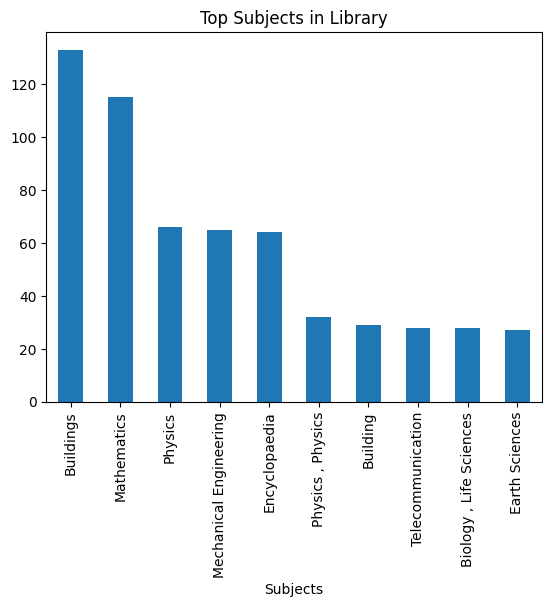

In [39]:
import matplotlib.pyplot as plt

df["Subjects"].value_counts().head(10).plot(kind="bar")
plt.title("Top Subjects in Library")
plt.show()

Evaluation (Objective 4)

Create Test Queries

In [40]:
test_queries = [
    "الذكاء الاصطناعي",
    "machine learning",
    "إدارة الأعمال",
    "الصحة",
    "data science"
]

Compare Both Systems

In [41]:
for query in test_queries:
    print(f"\nQuery: {query}")
    
    print("\nKeyword Search:")
    print(keyword_search(query))
    
    print("\nSemantic Search:")
    print(search_books(query))


Query: الذكاء الاصطناعي

Keyword Search:
Empty DataFrame
Columns: [Title, Author, Subjects]
Index: []

Semantic Search:
                                                  Title             Author  \
6053                سترى النور / تأليف ابراهيم بن محمد.      محمد، ابراهيم   
2021                Advanced Biology / By Michael Kent.       Kent Michael   
2012  Fundamentals of Heat and Mass Transfer / By Fr...  Incropera Frank P   
2013   Strategies for e-Business : Creating Value th...     Jelassi Tawfik   
2014     Management : An Introduction / By David Boddy.        Boddy David   

                                               Subjects  Similarity_Score  
6053  التنمية البشرية , علم النفس التطبيقي , الثقة ب...               0.0  
2021                                  Biology , Biology               0.0  
2012             Mass transfer , Mechanical Engineering               0.0  
2013  Management And Auxiliary Services , Electronic...               0.0  
2014  Management , Organising 

Define Relevance (Simple Method)

In [42]:
def is_relevant(result, query):
    return query.lower() in str(result).lower()

Calculate Precision

In [43]:
def precision_at_k(results, query, k=5):
    relevant = 0
    
    for i in range(min(k, len(results))):
        if is_relevant(results.iloc[i]["Subjects"], query):
            relevant += 1
            
    return relevant / k

Evaluate Both Models

In [44]:
for query in test_queries:
    semantic_results = search_books(query)
    keyword_results = keyword_search(query)
    
    sem_precision = precision_at_k(semantic_results, query)
    key_precision = precision_at_k(keyword_results, query)
    
    print(f"\nQuery: {query}")
    print(f"Keyword Precision: {key_precision}")
    print(f"Semantic Precision: {sem_precision}")


Query: الذكاء الاصطناعي
Keyword Precision: 0.0
Semantic Precision: 0.0

Query: machine learning
Keyword Precision: 0.2
Semantic Precision: 0.2

Query: إدارة الأعمال
Keyword Precision: 0.6
Semantic Precision: 0.4

Query: الصحة
Keyword Precision: 0.0
Semantic Precision: 0.0

Query: data science
Keyword Precision: 0.0
Semantic Precision: 0.0


(UPGRADE): Create Ground Truth Dataset

In [45]:
ground_truth = {
    "الذكاء الاصطناعي": ["ذكاء", "Artificial Intelligence"],
    "machine learning": ["machine learning", "تعلم"],
    "إدارة الأعمال": ["إدارة", "business"],
    "الصحة": ["health", "صحة"],
    "data science": ["data", "علم البيانات"]
}

In [46]:
def is_relevant_advanced(text, keywords):
    text = str(text).lower()
    for word in keywords:
        if word.lower() in text:
            return True
    return False

Precision + Recall

In [47]:
def evaluate_model(query, model_func, k=5):
    results = model_func(query, top_n=k)
    
    keywords = ground_truth.get(query, [])
    
    relevant_found = 0
    
    for i in range(len(results)):
        text = str(results.iloc[i]["Subjects"]) + " " + str(results.iloc[i]["Title"])
        
        if is_relevant_advanced(text, keywords):
            relevant_found += 1
    
    precision = relevant_found / k
    
    # Assume total relevant = len(keywords) (approximation)
    recall = relevant_found / len(keywords) if len(keywords) > 0 else 0
    
    # F1-score
    if precision + recall > 0:
        f1 = 2 * (precision * recall) / (precision + recall)
    else:
        f1 = 0
    
    return precision, recall, f1

Compare Models

In [48]:
for query in ground_truth.keys():
    p1, r1, f1_1 = evaluate_model(query, keyword_search)
    p2, r2, f1_2 = evaluate_model(query, search_books)
    
    print(f"\nQuery: {query}")
    
    print("Keyword Search:")
    print(f"Precision: {p1:.2f}, Recall: {r1:.2f}, F1: {f1_1:.2f}")
    
    print("Semantic Search:")
    print(f"Precision: {p2:.2f}, Recall: {r2:.2f}, F1: {f1_2:.2f}")


Query: الذكاء الاصطناعي
Keyword Search:
Precision: 0.00, Recall: 0.00, F1: 0.00
Semantic Search:
Precision: 0.00, Recall: 0.00, F1: 0.00

Query: machine learning
Keyword Search:
Precision: 0.40, Recall: 1.00, F1: 0.57
Semantic Search:
Precision: 0.20, Recall: 0.50, F1: 0.29

Query: إدارة الأعمال
Keyword Search:
Precision: 0.80, Recall: 2.00, F1: 1.14
Semantic Search:
Precision: 0.80, Recall: 2.00, F1: 1.14

Query: الصحة
Keyword Search:
Precision: 0.00, Recall: 0.00, F1: 0.00
Semantic Search:
Precision: 0.00, Recall: 0.00, F1: 0.00

Query: data science
Keyword Search:
Precision: 0.40, Recall: 1.00, F1: 0.57
Semantic Search:
Precision: 0.60, Recall: 1.50, F1: 0.86


Visualize Results

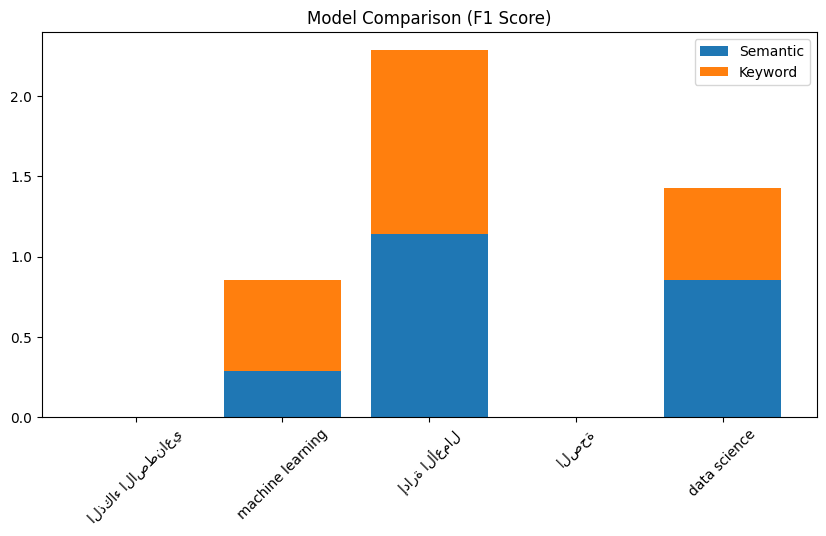

In [49]:
import matplotlib.pyplot as plt

semantic_scores = []
keyword_scores = []

for query in ground_truth.keys():
    _, _, f1_sem = evaluate_model(query, search_books)
    _, _, f1_key = evaluate_model(query, keyword_search)
    
    semantic_scores.append(f1_sem)
    keyword_scores.append(f1_key)

labels = list(ground_truth.keys())

x = range(len(labels))

plt.figure(figsize=(10,5))
plt.bar(x, semantic_scores, label="Semantic")
plt.bar(x, keyword_scores, bottom=semantic_scores, label="Keyword")

plt.xticks(x, labels, rotation=45)
plt.title("Model Comparison (F1 Score)")
plt.legend()
plt.show()

Top Subjects

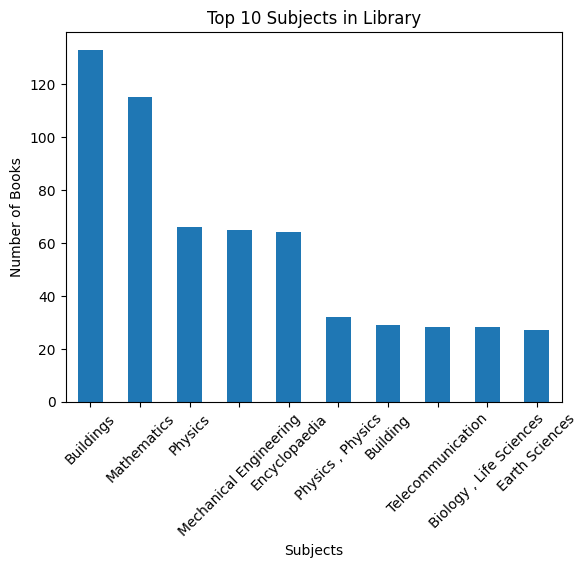

In [50]:
import matplotlib.pyplot as plt

df["Subjects"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Subjects in Library")
plt.xlabel("Subjects")
plt.ylabel("Number of Books")
plt.xticks(rotation=45)
plt.show()

Books per Year

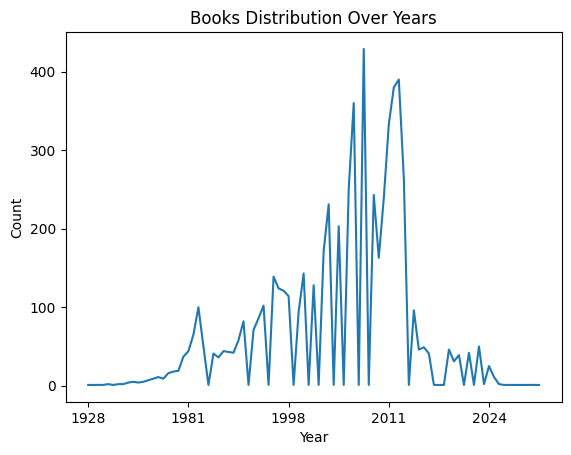

In [51]:
df["Publication_Year"].value_counts().sort_index().plot()
plt.title("Books Distribution Over Years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

Missing Data Analysis

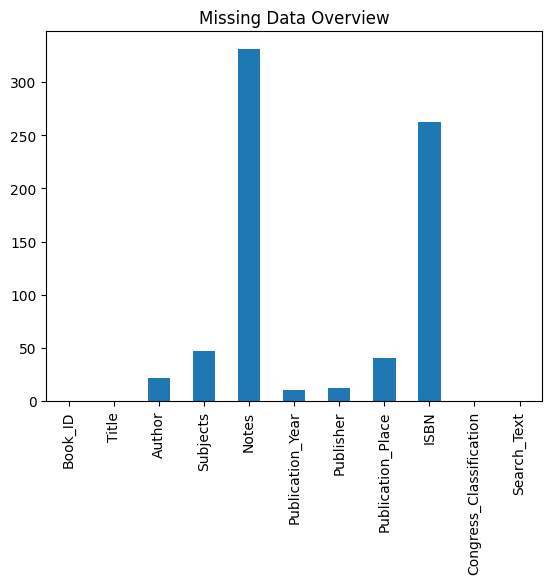

In [52]:
df.isnull().sum().plot(kind="bar")
plt.title("Missing Data Overview")
plt.show()